# DS4200 Homework 1

Due: Friday Jan 16th @ 11:59 PM EST

### Submission Instructions
Submit this `ipynb` file included with the coding results to Gradescope (this can also be done via the assignment on Canvas).  To ensure that your submitted files represent your latest code, make sure to give a fresh `Kernel > Restart & Run All` just before uploading the files to gradescope. **Please re-name the file to include your name.**

### Tips for success
- Start early
- Make use of Piazza
- Make use of Office hour
- Remember to use cells and headings to make the notebook easy to read (if a grader cannot find the answer to a problem, you will receive no points for it)
- Under no circumstances may one student view or share their ungraded homework or quiz with another student [(see also)](http://www.northeastern.edu/osccr/academic-integrity), though you are welcome to **talk about** (not show each other) the problems.

### Part 1 - Bad examples (20 points)

For the following figures extracted from online sources. Write 2 or 3 sentences for each to explain why it could be a bad example of visualization. Which design rules of thumbs or graphical integrity it may violated (if any) and how to re-design into a better one. 

##### Question 1 (5 pts)

The figure shows the numbers of female and male passengers on the Titanic traveling in 1st, 2nd, and 3rd class, shown as a 3D stacked bar plot. 

<div style="text-align: center;">
<img src="https://i.ibb.co/njznJtt/hw1-1.png" alt="hw1-1" border="0" width = 300>
</div>

This graph violates graphical integreity and the data ink ratio principel by using unnecessary 3D perspective that makes it diffcault to accuratly compare values across the classes. The depth dimensions added makes it visually complex to figure out the exact counts/numerical values and making bars harder to align to the grid lines. A simple 2D grouped or stacked bar chart would of allow for cleaer and more accurate comparisons. 

##### Question 2 (5 pts)

The figure shows the dollars of billions in sales for large fast food company. It also tries to compare the sales number with the GDP of Afghanistan in the same year. 

<div style="text-align: center;">
<img src="https://i.ibb.co/fSthBTJ/hw1-2.jpg" alt="hw1-2" border="0" border="0" width = 400>
</div>

This graph violates data ink ratio principle by using decorative company logos of irregular shapes and sized that add no meaningful information. The varying logo shapes makes visual compariosn confusing and arbitary, forcing views to rely entirely on text lables rather than visual represenation. A simple bar chat would provide both visual and numerical comparison and the Afghanistan GDP should be removed or be given more context. 

##### Question 3 (5 pts)

The figure is about the change of race proportions in the US from 1960 to 2060(estimated). 

<div style="text-align: center;">
<img src="https://i.ibb.co/5hf0hV6/hw1-3.png" alt="hw1-3" border="0" width = 300>
</div>

The visualization violates graphical integrity by using geogrpahic map to represent demographic proportions, where the spatial layout and irregular shape create misleading visual distortions unrelated to the actual data. The slanted color bands across the map suggest geogrphaic varaitons in percentage, and the irregular divisons make visual comaprion across locations hard. A stacked bar chart or area chart showing the three differnt locations would be better at displaying the proportions. 

##### Question 4 (5 pts)

<div style="text-align: center;">
<img src="https://i.ibb.co/7CSkGx4/hw1-5.png" alt="hw1-5" border="0" width = 300>
</div>

This visualization violates the data-ink ratio principle by attempting to show all 50 states in a single pie chart with tiny, overlapping slices and cluttered labels that are impossible to read or compare accurately. The excessive number of categories makes visual comparison difficult, and the overlapping text labels obscure the data. A better redesign would use a bar chart showing states ranked by the metric being measured, or a map with color coding to show geographic patterns, allowing viewers to actually distinguish between values.

### Part 2 - Basic statistical data visualization with Python (50 points)

Install vega datasets and use the Seattle weather data. It shows that daily Seattle weather in 4 years. Load the data and generate corresponding data visualizations. Make sure each figure has title, labels and legends if necessary. Add one or two sentences for question 1 to 5 to talk about what you have learned from the figure. 

In [1]:
pip install vega_datasets

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from vega_datasets import data

weather = data.seattle_weather()
weather.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


##### Question 1 (5 pts)

Generate a data visualization to show the relationship between precipitation and max temperature.  

Index(['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather'], dtype='object')


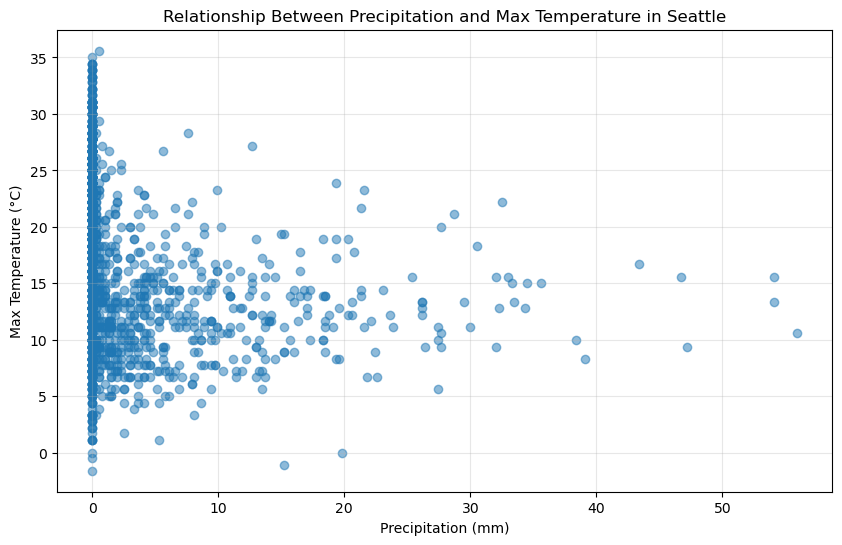

In [3]:
print(weather.columns)
plt.figure(figsize=(10,6))
plt.scatter(weather['precipitation'], weather['temp_max'], alpha=0.5)
plt.xlabel('Precipitation (mm)')
plt.ylabel('Max Temperature (°C)')
plt.title('Relationship Between Precipitation and Max Temperature in Seattle')
plt.grid(True, alpha=0.3)
plt.show()

The scatter plot shows the relationship between precipitation and max temperature in Seattle. There is a negative relationship between precipitation and maximum temperature, where days with more rainfall tend to have cooler temperatures. Most data points are concentrated near zero precipitation with temperatures ranging from 5-35°C, while days with significant precipitation (above 10mm) rarely exceed 25°C.

##### Question 2 (5 pts)

Generate a data visualization to show the relationship between max temperature and weather type.  

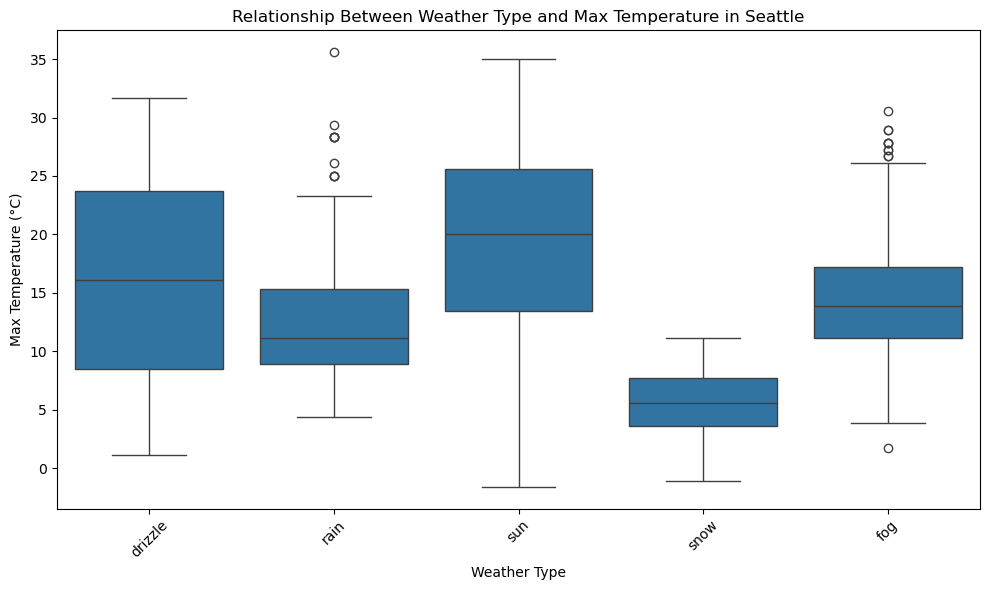

In [4]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='weather', y='temp_max', data=weather)
plt.xlabel('Weather Type')
plt.ylabel('Max Temperature (°C)')
plt.title('Relationship Between Weather Type and Max Temperature in Seattle')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The box plot reveals that sunny weather in Seattle corresponds with the highest maximum temperatures, with a median around 20°C and reaching up to 35°C. In contrast, rainy and snowy conditions show significantly cooler temperatures, with snow having the lowest median around 5°C and rain around 11°C, indicating a clear relationship between weather type and temperature.

##### Question 3 (5 pts)

Generate a data visualization to show the relationship between max temperature and min temperature, and then show different color for differnet weather type. Customize your color choice. 

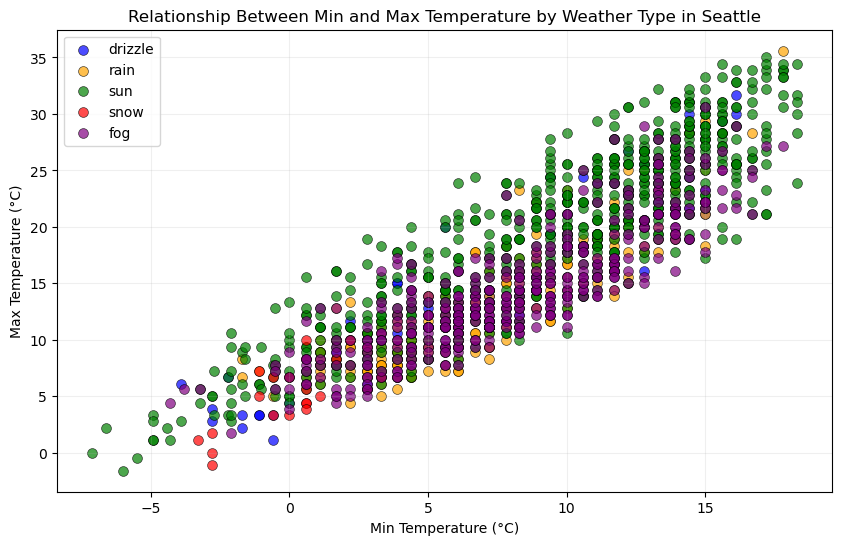

In [5]:
plt.figure(figsize=(10, 6))

weather_types = weather['weather'].unique()
colors = ['blue', 'orange', 'green', 'red', 'purple']

for i, weather_type in enumerate(weather_types):
    subset = weather[weather['weather'] == weather_type]
    plt.scatter(subset['temp_min'], subset['temp_max'], 
                label=weather_type, alpha=0.7, color=colors[i % len(colors)], s=50, edgecolors='black', linewidth=0.5)

plt.xlabel('Min Temperature (°C)')
plt.ylabel('Max Temperature (°C)')
plt.title('Relationship Between Min and Max Temperature by Weather Type in Seattle')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

The scatter plot shows a strong positive linear relationship between minimum and maximum temperatures, where higher minimum temperatures correspond with higher maximum temperatures across all weather types. Sunny days (green) dominate the warmer temperature ranges, while snowy days (red) appear only in the coldest conditions. Rain (orange), drizzle (blue), and fog (purple) show considerable overlap in the moderate temperature ranges, indicating similar temperature patterns for these weather conditions.

##### Question 4 (5 pts) 

Generate a data visualization to show the relationship between max temperature, min temperature and wind speed. Notice that wind speed is a continous variable and do not to use a 3D plot. 

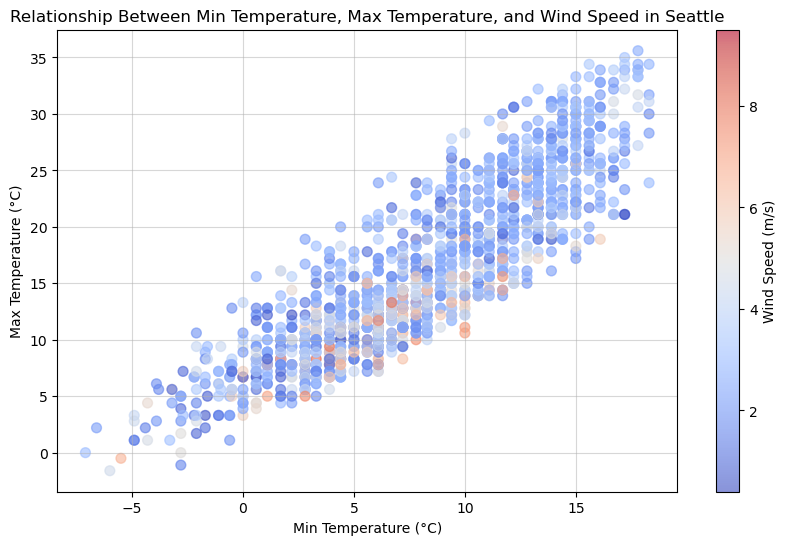

In [6]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(weather['temp_min'], weather['temp_max'], 
                     c=weather['wind'], cmap='coolwarm', alpha=0.6, s=50)

plt.xlabel('Min Temperature (°C)')
plt.ylabel('Max Temperature (°C)')
plt.title('Relationship Between Min Temperature, Max Temperature, and Wind Speed in Seattle')
plt.colorbar(scatter, label='Wind Speed (m/s)')
plt.grid(True, alpha=0.5)
plt.show()

The scatter plot shows a strong positive relationship between minimum and maximum temperatures, with wind speed represented by color intensity. Days with higher wind speeds (shown in red/orange) appear scattered throughout the temperature ranges without a clear pattern, while lower wind speeds (shown in blue) are more common. This suggests that wind speed doesn't have a strong relationship with the min-max temperature correlation.

##### Question 5 (8 pts)

Calculate the average temperature for each day (average on min and max). Plot the average temperature with the date.

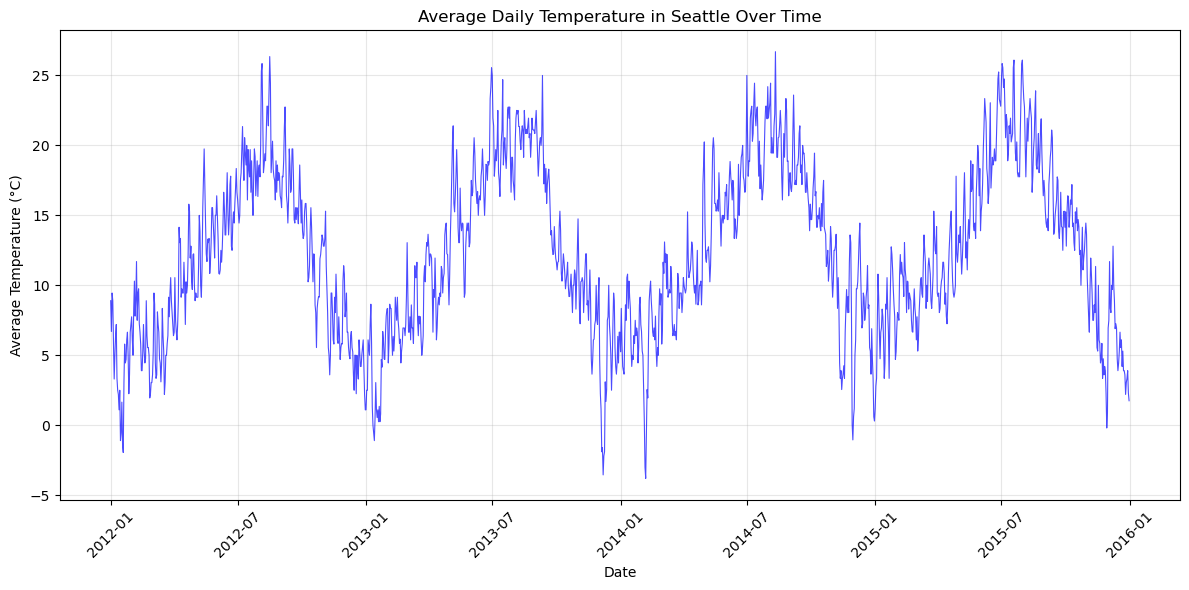

In [7]:
weather['temp_avg'] = (weather['temp_max'] + weather['temp_min']) / 2

plt.figure(figsize=(12, 6))
plt.plot(weather['date'], weather['temp_avg'], linewidth=0.8, color='blue', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Average Temperature (°C)')
plt.title('Average Daily Temperature in Seattle Over Time')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The line plot shows seasonal temperature patterns in Seattle over the four year period, with temperatures peaking during summer months (around 20-25°C) and dropping to their lowest in winter months (around 0-5°C). The cyclical pattern repeats consistently across all four years, demonstrating Seattle's predictable seasonal temperature variation with relatively mild winters and warm summers.

##### Question 6 (12 pts)

Now, let's try to create another categorical variable in this dataset. Make a new variable called "wind_group" such that it divides the wind spend into 3 groups, low, mid and high. You can use quantiles to divide the group. Then use "groupby" function to get a count table to show the count for each combination of the wind speed group and weather type. For example, get a table similar to this one:

In [8]:
import pandas as pd
counts = {
    "first": ["A", "A", "B", "B"],
    "second": ["C", "D", "C", "D"], 
    "count": [10, 1, 3, 7]
}
counts = pd.DataFrame(counts)
counts

,first,second,count
0,A,C,10
1,A,D,1
2,B,C,3
3,B,D,7


Then use following sample code to make a similar sankey diagram with the Weather data. 

In [9]:
import plotly.graph_objects as go

labels = ["A", "B", "C", "D"]
label_to_index = {label: i for i, label in enumerate(labels)}

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label = labels
    ),
    link=dict(
        source=counts["first"].map(label_to_index),
        target=counts["second"].map(label_to_index),
        value=counts["count"]
    )
)])

# Update the layout and show the diagram
fig.update_layout(title_text="Sample Sankey Diagram")
fig.show()

In [10]:
import plotly.graph_objects as go


In [11]:
import pandas as pd
weather['wind_group'] = pd.qcut(weather['wind'], q=3, labels=['low', 'mid', 'high'])
counts = weather.groupby(['wind_group', 'weather']).size().reset_index(name='count')
print(counts)

   wind_group  weather  count
0         low  drizzle     35
1         low      fog    132
2         low     rain     63
3         low     snow      4
4         low      sun    279
5         mid  drizzle     12
6         mid      fog    110
7         mid     rain     84
8         mid     snow      3
9         mid      sun    255
10       high  drizzle      7
11       high      fog    169
12       high     rain    112
13       high     snow     16
14       high      sun    180


/var/folders/lz/sy4rpwps6yd4mtrx6l5vlr580000gn/T/ipykernel_32227/2917417220.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [12]:
# Create label mappings
wind_labels = ['low', 'mid', 'high']
weather_labels = ['drizzle', 'fog', 'rain', 'snow', 'sun']
all_labels = wind_labels + weather_labels

# Create index mappings
wind_to_index = {label: i for i, label in enumerate(wind_labels)}
weather_to_index = {label: i + len(wind_labels) for i, label in enumerate(weather_labels)}

# Create the Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=all_labels
    ),
    link=dict(
        source=counts['wind_group'].map(wind_to_index),
        target=counts['weather'].map(weather_to_index),
        value=counts['count']
    )
)])

fig.update_layout(title_text="Wind Speed Group and Weather Type Relationship in Seattle")
fig.show()

##### Question 7 (5 pts)

Now use the demo on this page: https://plotly.com/python/treemaps/ to make a tree map for wind_group and weather type. 

In [13]:
import plotly.express as px

fig = px.treemap(counts, 
                 path=['wind_group', 'weather'], 
                 values='count',
                 title='Treemap of Wind Speed Group and Weather Type in Seattle')
fig.show()

##### Question 8 (5 points)

Notice that both sankey diagram and tree map can be used when you want to visualize two categorical variables. However, in a few sentences, discuss when you will choose sankey plot over the tree map and vice versa.

A Sankey diagram is better for showing flow and connections between categories, emphasizing how one variable distributes into another with directional bands. A treemap is better for comparing relative sizes of all combinations at once in a compact, hierarchical layout. For our data, the Sankey diagram better illustrates how wind groups flow into weather types, while the treemap makes it easier to quickly compare the size of all wind-weather combinations.